1) Метод серединных квадратов
2. Метод серединных произведений
3) Метод перемешивания

На основе этих трёх алгоритмов создать свой алгоритм ГСЧ. 
Получить 1024 случайных числа, в отрезке $[-1; 1]$, имеющие 6 знаков после запятой

$R_0 = clock$ - часы минуты секунды

4) Построить график значение от времени

5) Посчитать $M$ - мат ожидание 
$$M = \frac{\sum_i^n a_i}{n} $$
$D$ - Дисперсия
$$D = \frac1{n}\sum_i^n(a_i - M)^2 $$
$\sigma$ - среднеквадратичное отклонение
$$\sigma = \sqrt{D}$$

In [24]:
import matplotlib.pyplot as plt
import time
import numpy as np

In [1]:
def GetMiddleOfNumber(number):
    str_num = str(number)
    
    middle = str_num[len(str_num) // 4:-len(str_num) // 4]
    
    return int(middle)

In [2]:
def MethodMiddleSquare(number, N=1):    
    num = number
    
    for _ in range(N):
        num = GetMiddleOfNumber(num)
        num *= num
    
        # print(num)
    return num

In [3]:
MethodMiddleSquare(12345678)

11943936

In [9]:
a = [1, 2, 3, 4, 5, 6]
a[2:], a[:2]

([3, 4, 5, 6], [1, 2])

In [7]:
def MethodMiddleMultiply(number, N=1): 
    R0 = 39572034
    R1 = number
    for _ in range(N):
        num = GetMiddleOfNumber(R1) * GetMiddleOfNumber(R0)
        R0 = R1
        R1 = num
    return R1

In [11]:
def MethodMiddleMixing(number, N=1):
    
    for _ in range(N):
        l = len(str(number)) // 4
        strnum = str(number)
        R0 = strnum[l:] + strnum[:l]
        R1 = strnum[-l:] + strnum[:-l]
        
        num0 = int(R0)
        num1 = int(R1)
        
        number = num0 + num1
        print(num0, num1, number)
    return number
    

In [ ]:
MethodMiddleMixing(12345678)

34567812 78123456 112691268


112691268

In [58]:
def my_random(r_0=None, M=100_000_000):
    if r_0 == None:
        import time
        current_time = time.time()
        r_0 = int(current_time * 100000)
    

    R0 = MethodMiddleMixing(r_0)
    R1 = MethodMiddleSquare(r_0)
    
    R0 = (R0 + MethodMiddleMultiply(R1)) % M
    
    R1 = (R1 + MethodMiddleMixing(R0)) % M
    
    R0 = MethodMiddleSquare(R0) % M
    R1 = MethodMiddleMixing(R1) % M
    
    result = int(R0 + R1) % 1_000_000
    return result


In [59]:
N = 1024

rand_arr = []

for _ in range(N):
    current_time = time.time()
    milliseconds = int(current_time * 100000)
    
    rand_arr.append(my_random(milliseconds))

489317094878177 878177489317094 1367494584195271
51279131 91315127 142594258
25493988 39882549 65376537
489317094901177 901177489317094 1390494584218271
53579131 91315357 144894488
55516990 69905551 125422541
489317094907177 907177489317094 1396494584224271
54179131 91315417 145494548
15522991 29911552 45434543
489317094912177 912177489317094 1401494584229271
54679131 91315467 145994598
65527991 79916552 145444543
489317094918177 918177489317094 1407494584235271
55279131 91315527 146594658
25533992 39922553 65456545
489317094923177 923177489317094 1412494584240271
55779131 91315577 147094708
75538992 89927553 165466545
489317094928177 928177489317094 1417494584245271
56279131 91315627 147594758
25543993 39932554 65476547
489317094933177 933177489317094 1422494584250271
56779131 91315677 148094808
75548993 89937554 165486547
489317094938177 938177489317094 1427494584255271
57279131 91315727 148594858
25553994 39942555 65496549
489317094943177 943177489317094 1432494584260271
57779131 91

In [60]:
def normalization(rand_arr):
    max_num = max(rand_arr)
    
    rand_arr = [rand_arr[i] - max_num / 2 for i in range(len(rand_arr))]
    
    rand_arr = [rand_arr[i] / max_num * 2 for i in range(len(rand_arr))]
    
    return rand_arr

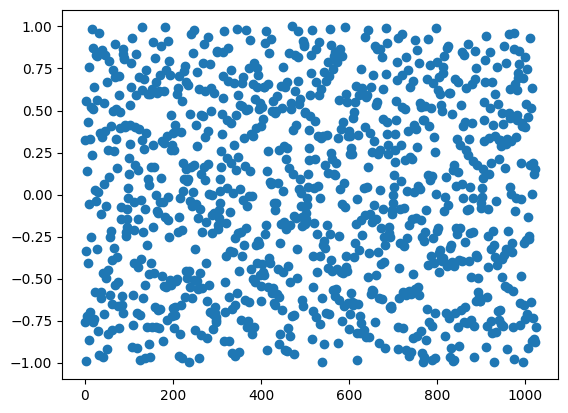

In [61]:
iters = [i for i in range(1024)]

rand_arr = normalization(rand_arr)

plt.scatter(iters, rand_arr)

In [62]:
M = sum(rand_arr) / N
M

-0.0002489878650128097

In [63]:
q_sum = 0
for el in rand_arr:
    q_sum += (el - M)**2
    
D = q_sum / N
sigma = np.sqrt(D)
D, sigma

(0.3210084151400106, np.float64(0.5665760453284365))

In [64]:
print('Характеристики генератора')
print(f'Математическое ожидание M = {M}')
print(f'Дисперсия D = {D}')
print(f'Среднеквадратическое отклонение = {sigma}')

Характеристики генератора
Математическое ожидание M = -0.0002489878650128097
Дисперсия D = 0.3210084151400106
Среднеквадратическое отклонение = 0.5665760453284365


In [ ]:
rand_arr[355]

-0.22324473621007127